<a href="https://colab.research.google.com/github/keswong/phd_listing_repo/blob/main/3_9_2_2_RF_TFIDF_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Classification on Social Cognitive Dimension**

## *Gridsearch for best hyperparameters using train_df*




In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
df = pd.read_pickle('.../PS_S_df_train_df.pkl')

X = np.vstack(df['Combined Vector'].values)
y = df['label']

sss = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=sss, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X, y)

best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best CV Score:", best_score)

results_df = pd.DataFrame(grid_search.cv_results_)
results_df.to_csv('.../PS_S_df_train_df_grid_search_details.csv', index=False)
print(f'Grid search result saved in .../PS_S_df_train_df_grid_search_details.csv')

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best CV Score: 0.5157750342935529
Grid search result saved in /content/drive/MyDrive/AIED25/M3_RF_TFIDF_ACOUSTIC/PS_S_df_train_df_grid_search_details.csv


## *Running RF with best performing hyperparameters*

Reading '/content/drive/MyDrive/AIED25/M3_RF_TFIDF_ACOUSTIC/PS_S_df_train_df_grid_search_details.csv'
Best Parameters: {'max_depth': None, 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(10), 'n_estimators': np.int64(200)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

         SS1      0.000     0.000     0.000        43
         SS2      0.496     0.576     0.533       245
         SS3      0.500     0.086     0.146        70
         SS4      0.000     0.000     0.000         6
         SS5      0.000     0.000     0.000        19
         SS6      0.000     0.000     0.000        25
         SS7      0.000     0.000     0.000         4
         SS8      0.000     0.000     0.000        10
         SC1      0.514     0.824     0.633       318
         SC2      0.574     0.337     0.425       172

   micro avg      0.512     0.512     0.512       912
   macro avg      0.208     0.182     0.174       912
weighted avg      0.459     0.512     0.455       912
 samples avg      0.512     0.512     0.512       912

Accuracy: 0.512
Precision: 0.459
Recall: 0.512
F1 Score: 0.455

AUROC for SS1: 0.806
AUROC for SS2: 0.767
AUROC for SS3: 0.794
AUROC for SS4: 0.705
AUROC for SS5: 

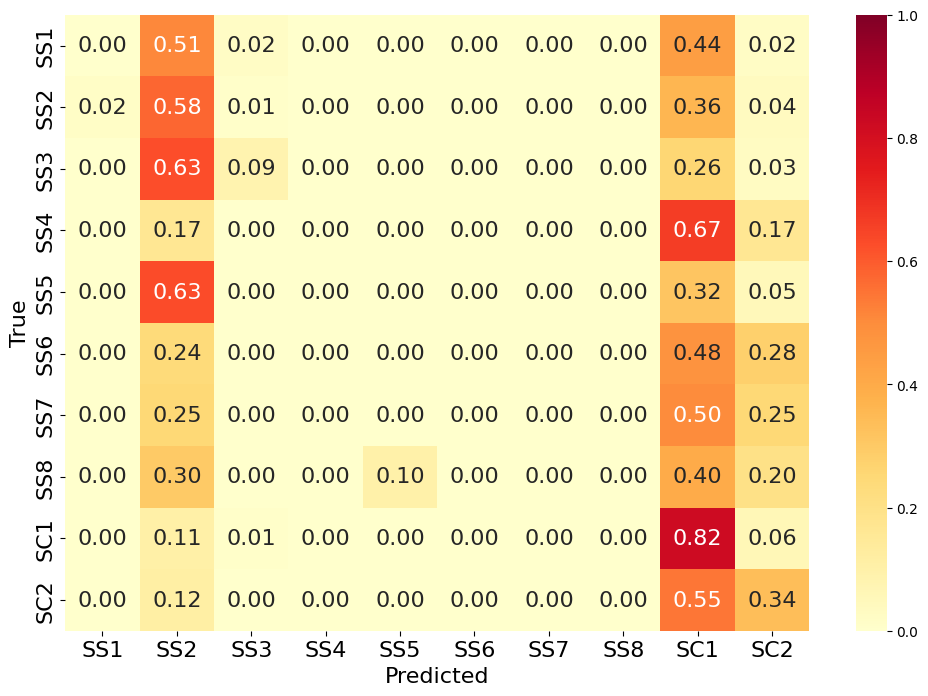

In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

train_df = pd.read_pickle('.../PS_S_df_train_df.pkl')
test_df = pd.read_pickle('.../PS_S_df_test_df.pkl')

label_dict = {'SS1': 0, 'SS2': 1, 'SS3': 2, 'SS4': 3, 'SS5': 4, 'SS6': 5, 'SS7': 6, 'SS8': 7, 'SC1': 8, 'SC2': 9}

results_df = pd.read_csv('.../PS_S_df_train_df_grid_search_details.csv')
print("Reading '.../PS_S_df_train_df_grid_search_details.csv'")

best_row = results_df.loc[results_df['rank_test_score'].idxmin()]
best_params = {col.replace('param_', ''): best_row[col] for col in results_df.columns if col.startswith('param_')}
best_params = {k: (None if pd.isna(v) else v) for k, v in best_params.items()}
best_params['max_depth'] = int(best_params['max_depth']) if best_params['max_depth'] is not None else None
print("Best Parameters:", best_params)

X_train = np.vstack(train_df['Combined Vector'].values)
y_train = train_df['label']
X_test = np.vstack(test_df['Combined Vector'].values)
y_test = test_df['label']

rf_classifier = RandomForestClassifier(**best_params, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
y_prob = rf_classifier.predict_proba(X_test)

def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}
    if isinstance(preds, pd.Series):
        preds = preds.to_numpy()
    if isinstance(labels, pd.Series):
        labels = labels.to_numpy()
    preds_flat = preds.flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat == label]
        y_true = labels_flat[labels_flat == label]
        accuracy = np.sum(y_preds == label) / len(y_true) * 100 if len(y_true) > 0 else 0
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds == label])}/{len(y_true)} = {accuracy:.1f}% \n')

y_true_binarized = label_binarize(y_test, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(y_pred, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')

print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

auroc_per_class = {}
for i, label in enumerate(label_dict.keys()):
    class_auroc = roc_auc_score(y_true_binarized[:, i], y_prob[:, i])
    auroc_per_class[label] = class_auroc
    print(f"AUROC for {label}: {class_auroc:.3f}")

class_counts = np.bincount(y_test)
class_weights = class_counts / len(y_test)
weighted_auroc = np.sum([class_weights[i] * auroc_per_class[label] for i, label in enumerate(label_dict.keys())])

print(f"Weighted AUROC: {weighted_auroc:.3f}")

def per_class_accuracy(cm):
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (FP + FN + TP)
    per_class_acc = (TP + TN) / np.sum(cm)
    return per_class_acc

per_class_acc = per_class_accuracy(cm)
for i, label in enumerate(label_dict.keys()):
    print(f"Per-class accuracy for {label}: {per_class_acc[i]:.3f}")

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 16}
)

ax.set_xlabel('Predicted', fontsize=16)
ax.set_ylabel('True', fontsize=16)
ax.tick_params(axis='both', labelsize=16)
plt.show()

# **Classification on Affective Dimension**

In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
df = pd.read_pickle('.../AFFECTIVE_df_train.pkl')

X = np.vstack(df['Combined Vector'].values)
y = df['label']

sss = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=sss, scoring='accuracy', n_jobs=-1, verbose=2)
grid_search.fit(X, y)
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print("Best Parameters:", best_params)
print("Best CV Score:", best_score)

results_df = pd.DataFrame(grid_search.cv_results_)
results_df.to_csv('.../affective_train_df_grid_search_details.csv', index=False)
print(f'Grid search result saved in .../affective_train_df_grid_search_details.csv')

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 300}
Best CV Score: 0.8585034013605443
Grid search result saved in /content/drive/MyDrive/AIED25/M3_RF_TFIDF_ACOUSTIC/affective_train_df_grid_search_details.csv


Reading '/content/drive/MyDrive/AIED25/M3_RF_TFIDF_ACOUSTIC/affective_train_df_grid_search_details.csv'
Best Parameters: {'max_depth': 30, 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(10), 'n_estimators': np.int64(300)}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

         AS1      0.829     0.851     0.840       114
         AS2      0.868     0.891     0.879       184
         AS3      0.000     0.000     0.000         8

   micro avg      0.853     0.853     0.853       306
   macro avg      0.566     0.581     0.573       306
weighted avg      0.831     0.853     0.842       306
 samples avg      0.853     0.853     0.853       306

Accuracy: 0.853
Precision: 0.831
Recall: 0.853
F1 Score: 0.842

AUROC for AS1: 0.941
AUROC for AS2: 0.916
AUROC for AS3: 0.988
Weighted AUROC: 0.927
Per-class accuracy for AS1: 0.879
Per-class accuracy for AS2: 0.853
Per-class accuracy for AS3: 0.974


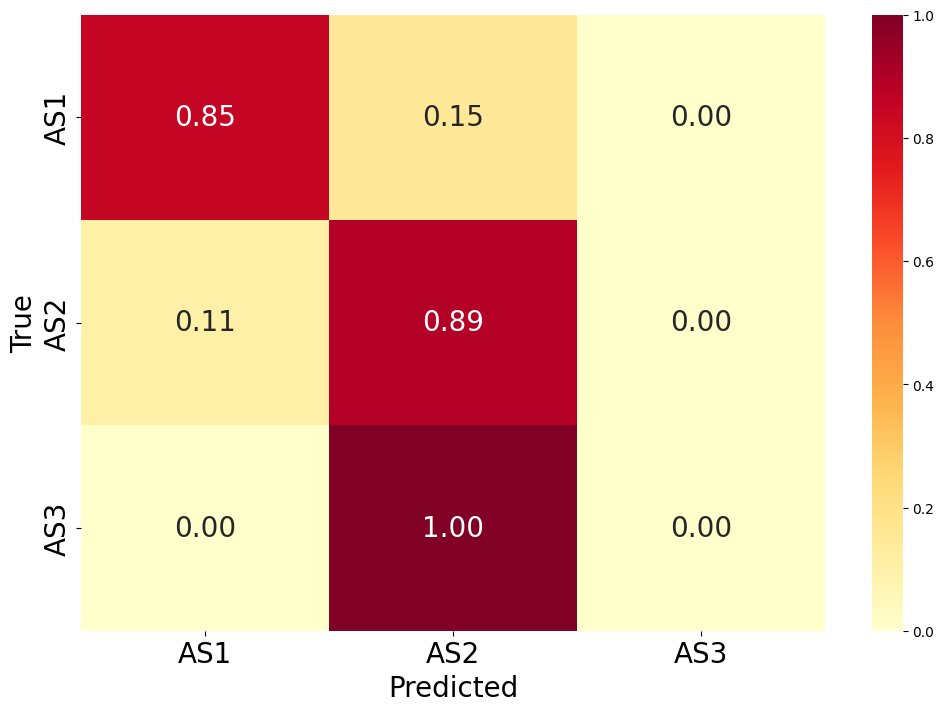

In [ ]:
%reset -f
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import matplotlib.pyplot as plt

train_df = pd.read_pickle('.../AFFECTIVE_df_train.pkl')
test_df = pd.read_pickle('.../AFFECTIVE_df_test.pkl')

label_dict = {'AS1': 0, 'AS2': 1, 'AS3': 2}
results_df = pd.read_csv('.../affective_train_df_grid_search_details.csv')
print("Reading '.../affective_train_df_grid_search_details.csv'")
best_row = results_df.loc[results_df['rank_test_score'].idxmin()]
best_params = {col.replace('param_', ''): best_row[col] for col in results_df.columns if col.startswith('param_')}
best_params = {k: (None if pd.isna(v) else v) for k, v in best_params.items()}
best_params['max_depth'] = int(best_params['max_depth']) if best_params['max_depth'] is not None else None
print("Best Parameters:", best_params)

X_train = np.vstack(train_df['Combined Vector'].values)
y_train = train_df['label']
X_test = np.vstack(test_df['Combined Vector'].values)
y_test = test_df['label']

rf_classifier = RandomForestClassifier(**best_params, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
y_prob = rf_classifier.predict_proba(X_test)

def accuracy_per_class(preds, labels):
    label_dict_inverse = {v: k for k, v in label_dict.items()}
    if isinstance(preds, pd.Series):
        preds = preds.to_numpy()
    if isinstance(labels, pd.Series):
        labels = labels.to_numpy()
    preds_flat = preds.flatten()
    labels_flat = labels.flatten()

    for label in np.unique(labels_flat):
        y_preds = preds_flat[labels_flat == label]
        y_true = labels_flat[labels_flat == label]
        accuracy = np.sum(y_preds == label) / len(y_true) * 100 if len(y_true) > 0 else 0
        print(f'Class: {label_dict_inverse[label]}')
        print(f'Accuracy: {len(y_preds[y_preds == label])}/{len(y_true)} = {accuracy:.1f}% \n')

y_true_binarized = label_binarize(y_test, classes=list(label_dict.values()))
y_pred_binarized = label_binarize(y_pred, classes=list(label_dict.values()))

# Classification report
report = classification_report(y_true_binarized, y_pred_binarized, target_names=label_dict.keys(), digits=3)
accuracy = accuracy_score(y_true_binarized, y_pred_binarized)
precision = precision_score(y_true_binarized, y_pred_binarized, average='weighted', zero_division=0)
recall = recall_score(y_true_binarized, y_pred_binarized, average='weighted')
f1 = f1_score(y_true_binarized, y_pred_binarized, average='weighted')

print('Classification Report:\n', report)
print(f'Accuracy: {accuracy:.3f}')
print(f'Precision: {precision:.3f}')
print(f'Recall: {recall:.3f}')
print(f'F1 Score: {f1:.3f}\n')
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

auroc_per_class = {}
for i, label in enumerate(label_dict.keys()):
    class_auroc = roc_auc_score(y_true_binarized[:, i], y_prob[:, i])
    auroc_per_class[label] = class_auroc
    print(f"AUROC for {label}: {class_auroc:.3f}")

class_counts = np.bincount(y_test)
class_weights = class_counts / len(y_test)
weighted_auroc = np.sum([class_weights[i] * auroc_per_class[label] for i, label in enumerate(label_dict.keys())])

print(f"Weighted AUROC: {weighted_auroc:.3f}")

def per_class_accuracy(cm):
    TP = np.diag(cm)
    FP = np.sum(cm, axis=0) - TP
    FN = np.sum(cm, axis=1) - TP
    TN = np.sum(cm) - (FP + FN + TP)
    per_class_acc = (TP + TN) / np.sum(cm)
    return per_class_acc

per_class_acc = per_class_accuracy(cm)
for i, label in enumerate(label_dict.keys()):
    print(f"Per-class accuracy for {label}: {per_class_acc[i]:.3f}")


fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    cbar=True,
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys(),
    vmin=0,
    vmax=1,
    ax=ax,
    annot_kws={"size": 20}
)

ax.set_xlabel('Predicted', fontsize=20)
ax.set_ylabel('True', fontsize=20)
ax.tick_params(axis='both', labelsize=20)
plt.show()